In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [39]:
df = pd.read_csv('../data/monthly_milk_production.csv',index_col='Date',parse_dates=True)
df.index.freq='MS'
df

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727
...,...
1975-08-01,858
1975-09-01,817
1975-10-01,827


<Axes: xlabel='Date'>

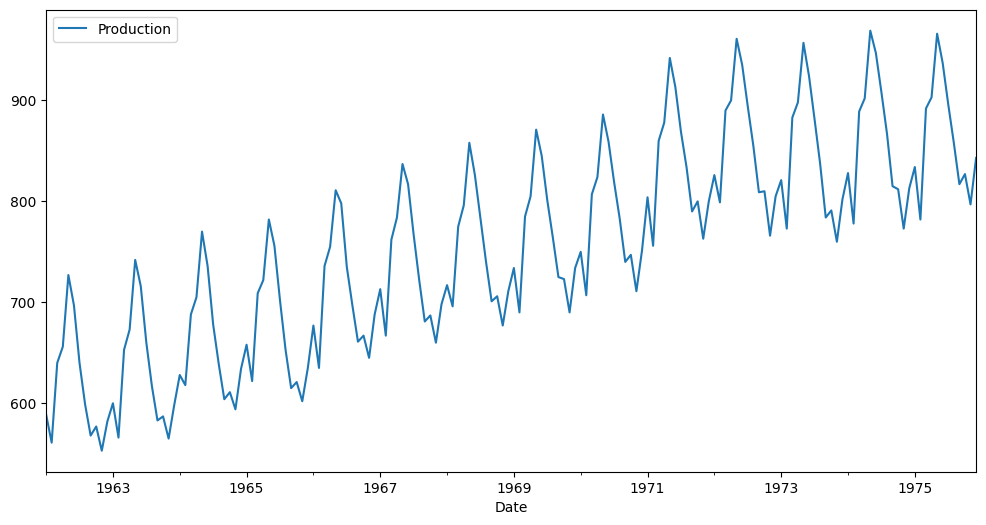

In [4]:
df.plot(figsize=(12,6))

<Figure size 1200x800 with 0 Axes>

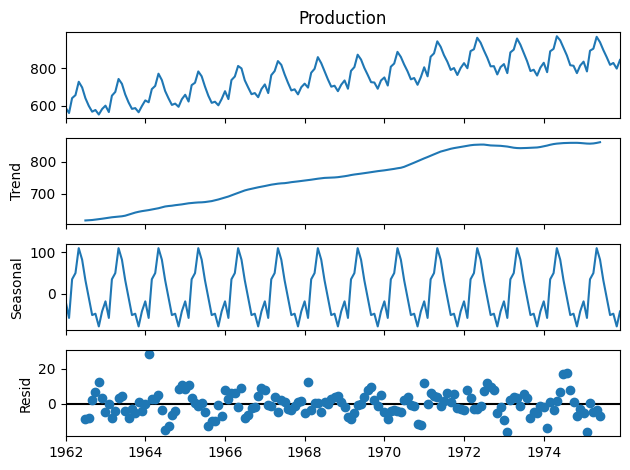

In [54]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposed_product = seasonal_decompose(df['Production'], model='additive')
plt.figure(figsize=(12,8))
decomposed_product.plot()
plt.show()

In [6]:
len(df) - 12

156

In [40]:
train = df.iloc[:156]
test = df.iloc[156:]

<Axes: xlabel='Date'>

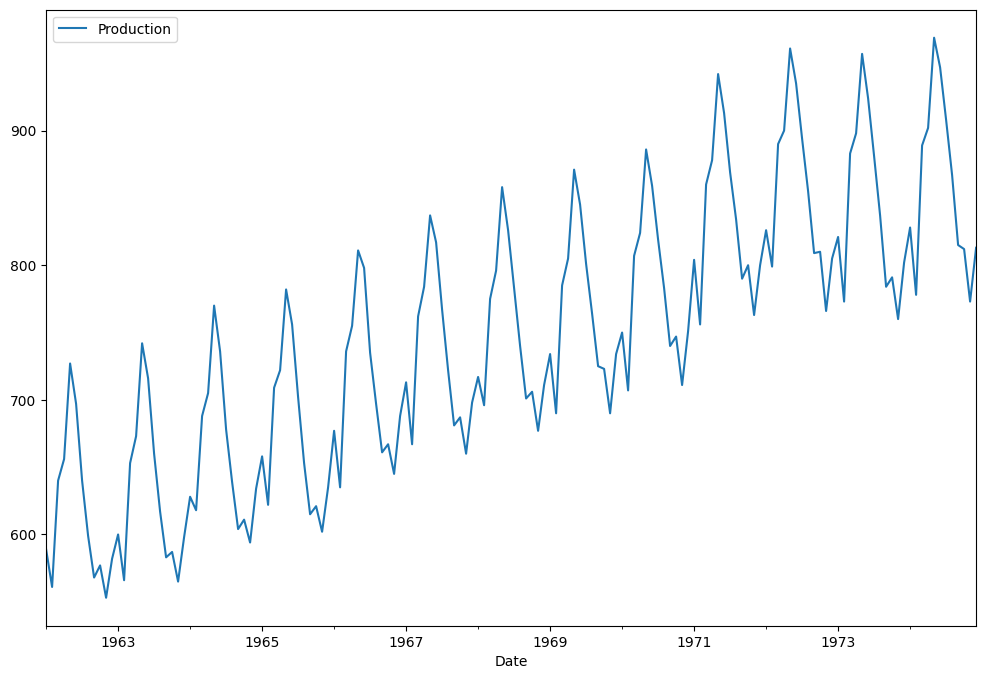

In [14]:
train.plot(figsize=(12,8))

<Axes: xlabel='Date'>

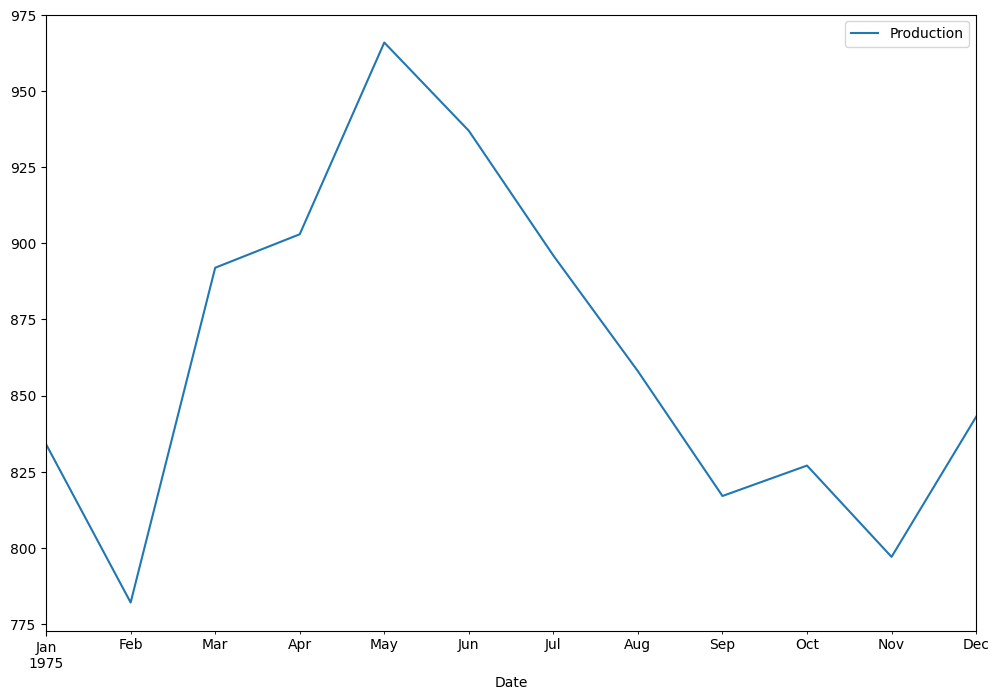

In [15]:
test.plot(figsize=(12,8))

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(train)
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [17]:
scaled_train

array([[0.08653846],
       [0.01923077],
       [0.20913462],
       [0.24759615],
       [0.41826923],
       [0.34615385],
       [0.20913462],
       [0.11057692],
       [0.03605769],
       [0.05769231],
       [0.        ],
       [0.06971154],
       [0.11298077],
       [0.03125   ],
       [0.24038462],
       [0.28846154],
       [0.45432692],
       [0.39182692],
       [0.25721154],
       [0.15384615],
       [0.07211538],
       [0.08173077],
       [0.02884615],
       [0.10817308],
       [0.18028846],
       [0.15625   ],
       [0.32451923],
       [0.36538462],
       [0.52163462],
       [0.43990385],
       [0.30048077],
       [0.20673077],
       [0.12259615],
       [0.13942308],
       [0.09855769],
       [0.19471154],
       [0.25240385],
       [0.16586538],
       [0.375     ],
       [0.40625   ],
       [0.55048077],
       [0.48798077],
       [0.35817308],
       [0.24038462],
       [0.14903846],
       [0.16346154],
       [0.11778846],
       [0.197

In [18]:
scaled_test

array([[0.67548077],
       [0.55048077],
       [0.81490385],
       [0.84134615],
       [0.99278846],
       [0.92307692],
       [0.82451923],
       [0.73317308],
       [0.63461538],
       [0.65865385],
       [0.58653846],
       [0.69711538]])

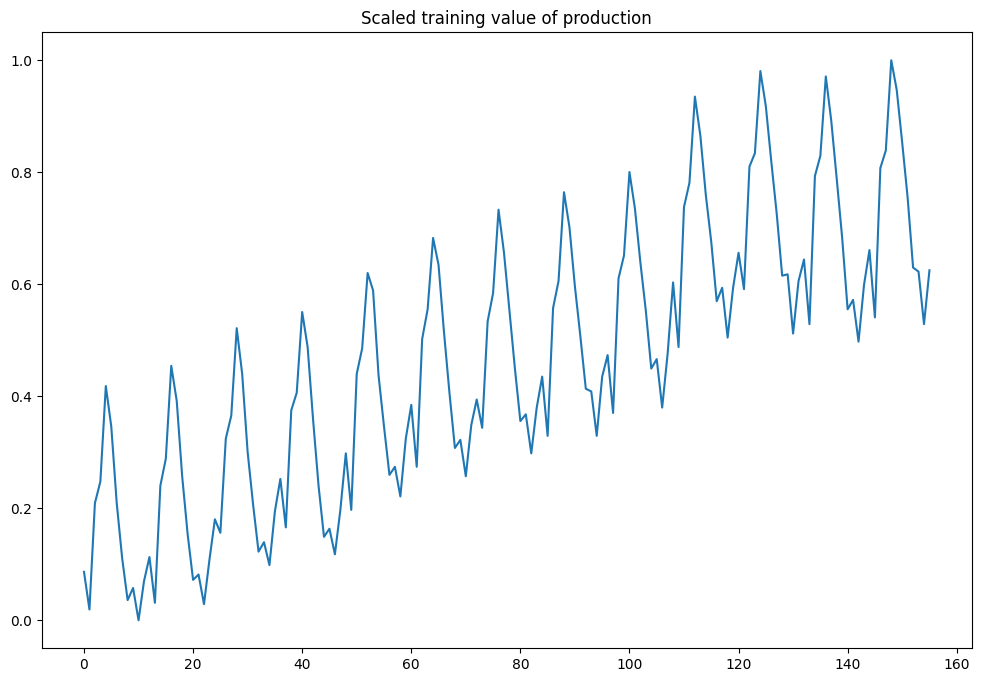

In [23]:
plt.figure(figsize=(12,8))
plt.title('Scaled training value of production')
plt.plot(scaled_train)
plt.show()

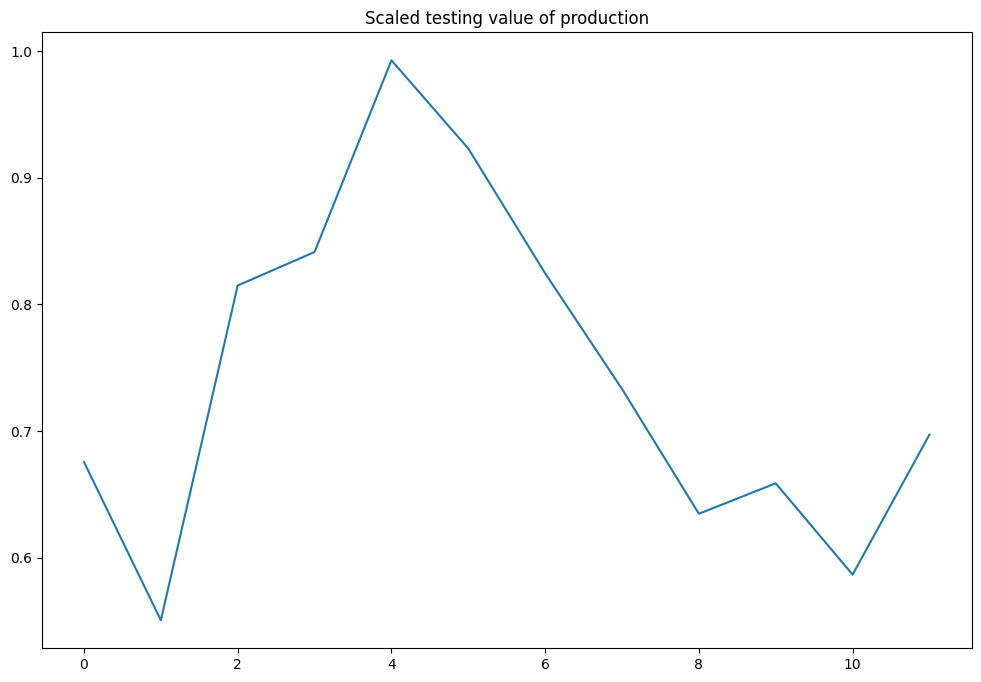

In [22]:
plt.figure(figsize=(12,8))
plt.title('Scaled testing value of production')
plt.plot(scaled_test)
plt.show()

# Step 1: Prepare the data for LSTM input
LSTMs expect the data in a specific format where each input sequence has an associated output. Since it's time series data, it’ll need to be structured in sequences with a chosen number of time steps.

## Create sequences and train test split
Using train_test_split can be a bit tricky in time series forecasting because, unlike traditional datasets, time series data requires maintaining the temporal order. Randomly splitting it would break that order, leading to "future" data points mixing with "past" ones in the training and test sets, which isn’t suitable for forecasting.

In time series, it’s generally better to split based on time, using the oldest data points for training and reserving the more recent data points for testing, as done earlier. To do the `train_test_split` for a preliminary split, consider shuffle=False in the `train_test_split` function.

Let’s say you want to predict the next month’s production based on the previous 12 months (1 year). Here’s how to set it up:

In [41]:
# Define function to create sequences
def create_sequences(data: np.ndarray, seq_length=12):
    x = []
    y = []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(x), np.array(y)

# Create sequences for training and testing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Define the sequence length
seq_length = 12

# Use train_test_split with shuffle=False to retain temporal order
train_data, test_data = train_test_split(df, test_size=0.2, shuffle=False)

# Scale the data
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)

# Create sequences from scaled_train and scaled_test
x_train, y_train = create_sequences(scaled_train, seq_length)
x_test, y_test = create_sequences(scaled_test, seq_length)

# Step 2: Build the LSTM model
Now, you can create the LSTM model using Keras.

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Build the model
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Check the model summary
model.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

# Step 3: Reshape data and train the model
Reshape x_train and x_test to have three dimensions (samples, time steps, features) because LSTMs expect input in this format.

In [43]:
# Reshape data
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

# Train the model
history = model.fit(x_train, y_train, epochs=50, validation_data=(x_test, y_test), verbose=1)

Epoch 1/50


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.2505 - val_loss: 0.4611
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1963 - val_loss: 0.3278
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1244 - val_loss: 0.1981
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0632 - val_loss: 0.0754
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0346 - val_loss: 0.0267
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0328 - val_loss: 0.0392
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0357 - val_loss: 0.0232
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0249 - val_loss: 0.0356
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0253 - val_loss: 0.0422
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0246 - val_loss: 0.0365
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0216 - val_loss: 0.0272
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0209 - val_loss: 0.0226
Epoch 13/50

In [59]:
dict(history.history)

{'loss': [0.23456647992134094,
  0.1741640716791153,
  0.1172015517950058,
  0.06290294229984283,
  0.028947295621037483,
  0.03507177531719208,
  0.03211721405386925,
  0.024108972400426865,
  0.025679882615804672,
  0.025721175596117973,
  0.023662423714995384,
  0.022525830194354057,
  0.02326126955449581,
  0.02296767383813858,
  0.02230636402964592,
  0.022094808518886566,
  0.021947043016552925,
  0.02143079787492752,
  0.02122603915631771,
  0.021212471649050713,
  0.02077740989625454,
  0.020770583301782608,
  0.02013009414076805,
  0.020124997943639755,
  0.019550705328583717,
  0.019134579226374626,
  0.018691251054406166,
  0.018275883048772812,
  0.017769260331988335,
  0.017166636884212494,
  0.016487501561641693,
  0.015775956213474274,
  0.01492882426828146,
  0.014306803233921528,
  0.013133199885487556,
  0.012684918940067291,
  0.012065017595887184,
  0.010487968102097511,
  0.010551325976848602,
  0.009380870498716831,
  0.008902131579816341,
  0.008423397317528725,


# Step 4: Make predictions and inverse scale them
After training, you can make predictions and invert the scaling to interpret them in the original scale.

In [48]:
# Make predictions
train_predictions = model.predict(x_train)
test_predictions = model.predict(x_test)

# Inverse transform predictions
train_predictions = scaler.inverse_transform(train_predictions)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predictions = scaler.inverse_transform(test_predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


# Step 5: Plot results
Visualize the model’s performance to see how well it forecasts milk production.

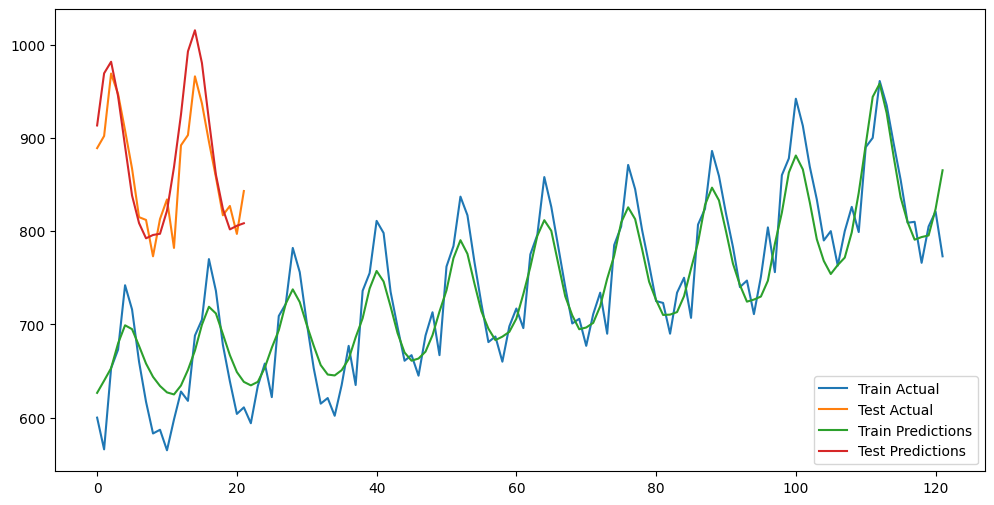

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(y_train_actual, label='Train Actual')
plt.plot(y_test_actual, label='Test Actual')
plt.plot(train_predictions, label='Train Predictions')
plt.plot(test_predictions, label='Test Predictions')
plt.legend()
plt.show()

# Error calculation
You can calculate error metrics like Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE) for time series forecasting models. These metrics help evaluate the accuracy of your model's predictions by comparing them to the actual values in your test set.

A quick rundown of these metrics in the context of time series forecasting:

- **MSE (Mean Squared Error)**: Measures the average of the squares of the errors. It gives higher weight to larger errors and is useful if you want to penalize larger deviations more heavily.

- **RMSE (Root Mean Squared Error)**: The square root of MSE. It provides an error metric in the same units as the data, making it easier to interpret.

- **MAE (Mean Absolute Error)**: The average of the absolute errors. Unlike MSE and RMSE, it does not give extra weight to larger errors, making it useful if all errors should be treated equally.

Here’s how to calculate these metrics after predicting values with the LSTM model:
### Explanation:
1. **Predictions**: The model’s predictions on the test set (`x_test`).
2. **Inverse Transform**: Since the data is scaled, apply `inverse_transform` to convert predictions and `y_test` back to their original scale for accurate error calculation.
3. **Calculate Errors**: Compute MSE, RMSE, and MAE by comparing the original-scale predictions with `y_test`.

Using these error metrics gives a comprehensive view of the model’s forecasting performance.

In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Make predictions using your LSTM model on the test data
predictions = model.predict(x_test)

# Reverse scaling (if you scaled your data before training)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate MSE, RMSE, and MAE
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Mean Squared Error: 1416.7090736397274
Root Mean Squared Error: 37.63919597493718
Mean Absolute Error: 28.718711159446006
